In [286]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [287]:
df = pd.read_csv('dataset/stormdata_1996_2013.csv')
df.shape

/var/folders/m7/yqngb7n958sd5lnk7by1q2lw0000gn/T/ipykernel_77224/791950472.py:1: DtypeWarning: Columns (26,28,29,34,35,37,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset/stormdata_1996_2013.csv')


(994039, 58)

In [288]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994039 entries, 0 to 994038
Data columns (total 58 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   BEGIN_YEARMONTH     994039 non-null  int64  
 1   BEGIN_DAY           994039 non-null  int64  
 2   BEGIN_TIME          994039 non-null  int64  
 3   END_YEARMONTH       994039 non-null  int64  
 4   END_DAY             994039 non-null  int64  
 5   END_TIME            994039 non-null  int64  
 6   EPISODE_ID          994039 non-null  int64  
 7   EVENT_ID            994039 non-null  int64  
 8   STATE               994038 non-null  object 
 9   STATE_FIPS          994038 non-null  float64
 10  YEAR                994039 non-null  int64  
 11  MONTH_NAME          994039 non-null  object 
 12  EVENT_TYPE          994039 non-null  object 
 13  CZ_TYPE             994039 non-null  object 
 14  CZ_FIPS             994039 non-null  int64  
 15  CZ_NAME             994039 non-nul

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE_FIPS,YEAR,...,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,LAST_MOD_DATE,LAST_MOD_TIME,LAST_CERT_DATE,LAST_CERT_TIME,ADDCORR_FLG,ADDCORR_DATE
count,994039.000000,994039.000000,994039.000000,994039.000000,994039.000000,994039.000000,9.940390e+05,9.940390e+05,994038.000000,994039.000000,...,567873.000000,567874.000000,351105.000000,351106.000000,4.463770e+05,446377.000000,4.463770e+05,446377.000000,37840.000000,3.784000e+04
mean,200515.128781,14.891068,1290.468152,200515.131411,16.544843,1488.680599,2.144254e+05,3.109488e+06,31.470924,2005.092126,...,37.989446,-64.087901,38.193559,-48.084223,4.552487e+07,4124.842346,2.010261e+07,1316.212988,1.053066,2.010506e+07
std,514.703215,9.178259,682.994668,514.703310,9.180232,613.744263,3.316139e+05,2.591636e+06,17.179113,5.146791,...,4.846587,80.801729,11.350832,99.060125,3.721479e+07,4036.234968,1.896445e+04,400.252899,0.224167,2.054233e+04
min,199601.000000,1.000000,0.000000,199601.000000,1.000000,0.000000,1.000000e+00,3.419000e+03,1.000000,1996.000000,...,-14.350000,-815.100000,-14.400000,-815.100000,2.006010e+07,0.000000,2.006010e+07,0.000000,1.000000,2.009041e+07
25%,200103.000000,7.000000,800.000000,200103.000000,9.000000,1145.000000,4.446800e+04,2.704935e+05,19.000000,2001.000000,...,34.650000,-96.430000,34.520000,-95.700000,2.009083e+07,1221.000000,2.008120e+07,1033.000000,1.000000,2.009041e+07
50%,200512.000000,15.000000,1500.000000,200512.000000,17.000000,1615.000000,8.527700e+04,5.177320e+06,30.000000,2005.000000,...,38.040000,-88.100000,37.830000,-86.720000,2.012013e+07,1717.000000,2.010102e+07,1318.000000,1.000000,2.009041e+07
75%,201003.000000,23.000000,1812.000000,201003.000000,25.000000,1920.000000,1.758730e+05,5.474706e+06,45.000000,2010.000000,...,41.420000,-78.450000,41.270000,76.180000,1.000000e+08,9999.000000,2.012052e+07,1556.000000,1.000000,2.013111e+07
max,201310.000000,31.000000,2359.000000,201310.000000,31.000000,2359.000000,1.152422e+06,5.725449e+06,99.000000,2013.000000,...,97.100000,171.370000,483.100000,815.100000,1.000000e+08,9999.000000,2.014011e+07,2359.000000,2.000000,2.014013e+07


## Data Cleaning

Review and clean the dataset by handling any missing values, removing duplicates, correcting inconesistencies, reformat unique data, and removing unused columns.

In [289]:
tornado_df = df[["BEGIN_YEARMONTH", "BEGIN_DAY", "END_YEARMONTH", "END_DAY", "STATE", "TOR_F_SCALE", "TOR_LENGTH", "TOR_WIDTH"]]
tornado_df.head()
tornado_df.shape
tornado_df.isnull().sum()

BEGIN_YEARMONTH         0
BEGIN_DAY               0
END_YEARMONTH           0
END_DAY                 0
STATE                   1
TOR_F_SCALE        969115
TOR_LENGTH         969143
TOR_WIDTH          969143
dtype: int64

In [290]:
tornado_df = tornado_df.dropna()
tornado_df.head()

,BEGIN_YEARMONTH,BEGIN_DAY,END_YEARMONTH,END_DAY,STATE,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH
1046,200801,7,200801,7,MISSOURI,EF0,0.07,20.0
1051,200801,7,200801,7,MISSOURI,EF0,0.17,25.0
1064,200801,7,200801,7,ILLINOIS,EF3,6.90,100.0
1066,200801,7,200801,7,ILLINOIS,EF3,6.30,100.0
1072,200801,7,200801,7,MISSOURI,EF0,0.30,40.0


In [291]:
# reformat date 
tornado_df["BEGIN_DATE"] = pd.to_datetime(tornado_df["BEGIN_YEARMONTH"].astype(str) + tornado_df["BEGIN_DAY"].astype(str), format="%Y%m%d")
tornado_df["END_DATE"] = pd.to_datetime(tornado_df["END_YEARMONTH"].astype(str) + tornado_df["END_DAY"].astype(str), format="%Y%m%d")
tornado_df = tornado_df.drop(columns=["BEGIN_YEARMONTH", "BEGIN_DAY", "END_YEARMONTH", "END_DAY"])

In [292]:
# change all columns name to lowercase
tornado_df.columns = map(str.lower, tornado_df.columns)

In [293]:
tornado_df.head()

,state,tor_f_scale,tor_length,tor_width,begin_date,end_date
1046,MISSOURI,EF0,0.07,20.0,2008-01-07,2008-01-07
1051,MISSOURI,EF0,0.17,25.0,2008-01-07,2008-01-07
1064,ILLINOIS,EF3,6.90,100.0,2008-01-07,2008-01-07
1066,ILLINOIS,EF3,6.30,100.0,2008-01-07,2008-01-07
1072,MISSOURI,EF0,0.30,40.0,2008-01-07,2008-01-07


## Deliverable 1

### Tornadoes per Year (1996-2013)

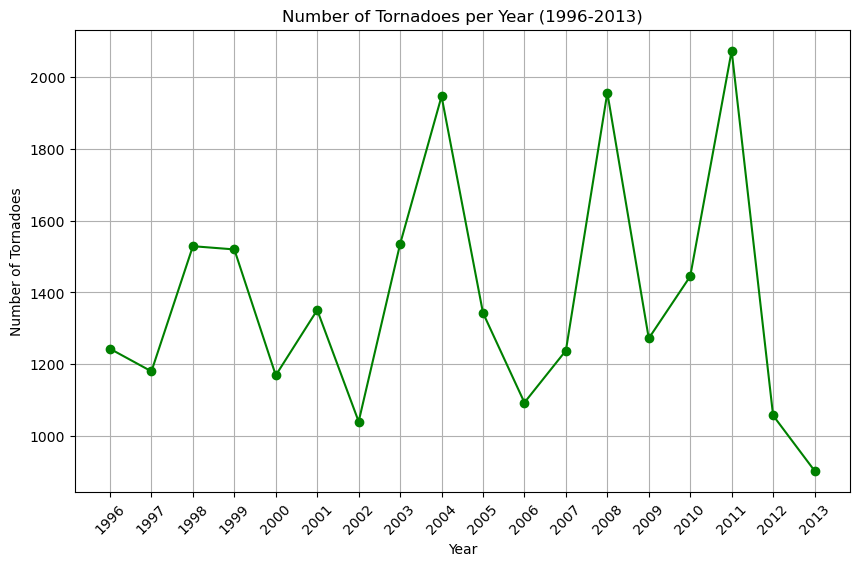

In [294]:
year = tornado_df['begin_date'].dt.year
yearly_trends = tornado_df.groupby(year).size()

plt.figure(figsize=(10, 6))
plt.plot(yearly_trends.index, yearly_trends.values, marker="o", color="green")
# matplotlib auto scale the asix tics, so we need to set the x-ticks to prevent floats in x-axis
plt.xticks(yearly_trends.index, rotation=45) 
plt.title("Number of Tornadoes per Year (1996-2013)")
plt.xlabel("Year")
plt.ylabel("Number of Tornadoes")
plt.grid(True)
plt.show()

This line chart tracks how many tornadoes happened each year over about two decades. The numbers bounce up and down quite a bit. Some years like 2004, 2008, and 2011 saw huge spikes above 1,900 tornadoes, while 2002 and 2013 were relatively quiet. This tells us tornado activity is very unpredictable year to year, with no steady trend upward or downward.

### Tornadoes per Month (1996-2013)

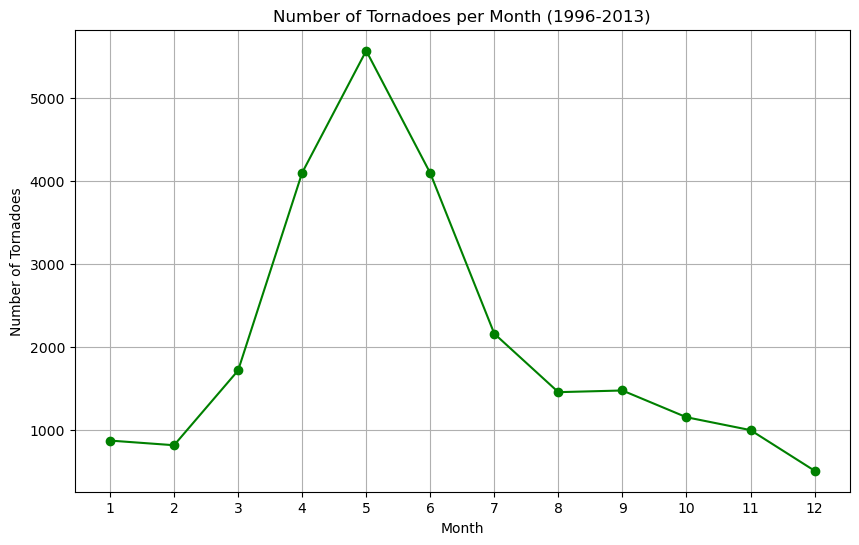

In [295]:
tornado_df['month'] = tornado_df['begin_date'].dt.month
monthly_trends = tornado_df.groupby('month').size()

plt.figure(figsize=(10, 6))
plt.plot(monthly_trends.index, monthly_trends.values, marker="o", color="green")
plt.xticks(monthly_trends.index)
plt.title("Number of Tornadoes per Month (1996-2013)")
plt.xlabel("Month")
plt.ylabel("Number of Tornadoes")
plt.grid(True)
plt.show()

This chart adds up all tornadoes recorded in each calendar month across the whole 18-year period. May is by far the most dangerous month with over 5,500 tornadoes total, followed by April and June. Tornadoes basically go into "off season" in winter. January, February, and December are the quietest months.

### Tornadoes per Season (1996-2013)

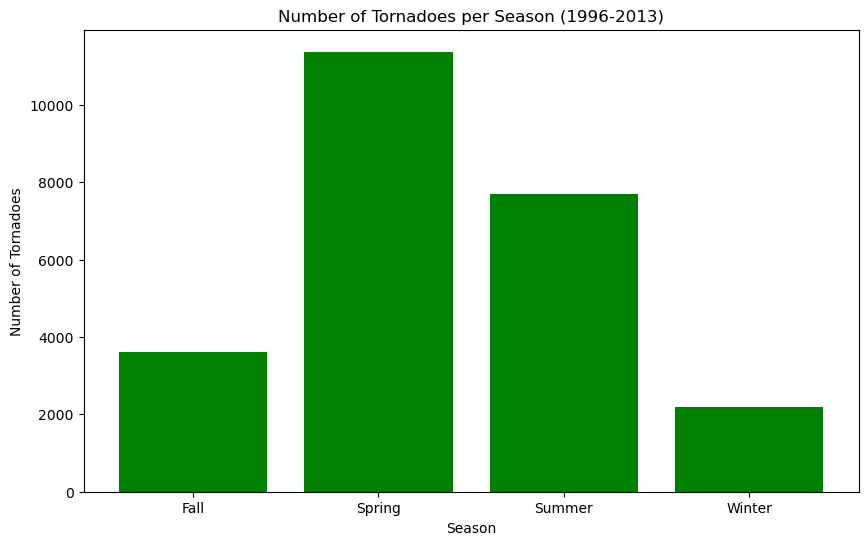

In [296]:
# define a function to map month to season
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    else:
        return "Winter"

# apply the season function to the month 
tornado_df['season'] = tornado_df['month'].apply(get_season)
seasonal_trends = tornado_df.groupby('season').size()

plt.figure(figsize=(10, 6))
plt.bar(seasonal_trends.index, seasonal_trends.values, color="green")
plt.title("Number of Tornadoes per Season (1996-2013)")
plt.xlabel("Season")
plt.ylabel("Number of Tornadoes")
plt.show()

This bar chart groups tornadoes into the four seasons. Spring dominates with over 11,000 total tornadoes, more than summer, fall, and winter combined. This makes sense given what we saw in Chart 2: the peak months (April-June) all fall in spring.

### Top 10 States with Most Tornadoes (1996-2013)

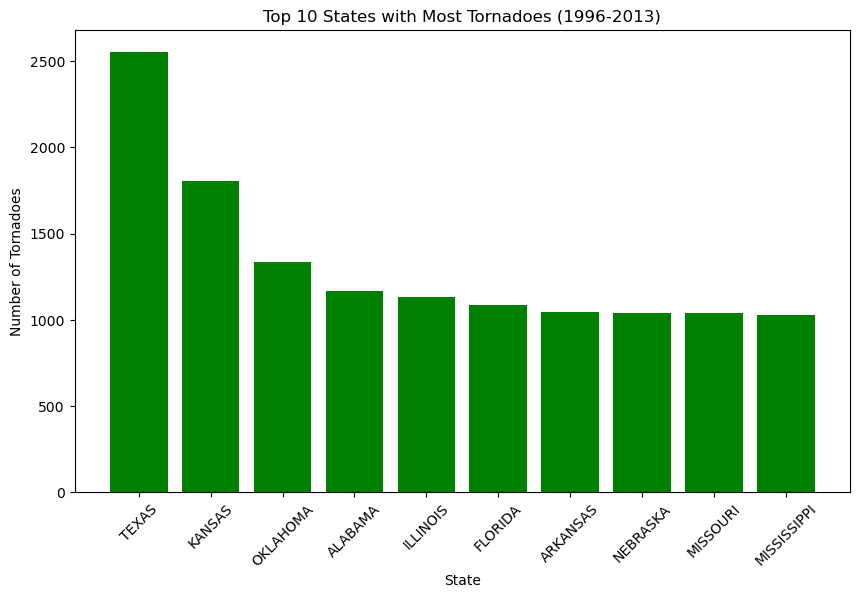

In [297]:
state_counts = tornado_df.groupby("state").size()
top_states = state_counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_states.index, top_states.values, color="green")
plt.xticks(rotation=45)
plt.title("Top 10 States with Most Tornadoes (1996-2013)")
plt.xlabel("State")
plt.ylabel("Number of Tornadoes")
plt.show()

This chart ranks the states hit hardest by tornadoes. Texas is the clear leader with about 2,550 tornadoes, well ahead of Kansas in second place (~1,800). 
The rest of the top 10, Oklahoma, Alabama, Illinois, Florida, Arkansas, Nebraska, Missouri, and Mississippi, are all clustered between roughly 1,000 and 1,350. Most of these states sit in the famous "Tornado Alley" region of the central US.

### Tornado Intensity Ratings (1996-2013)

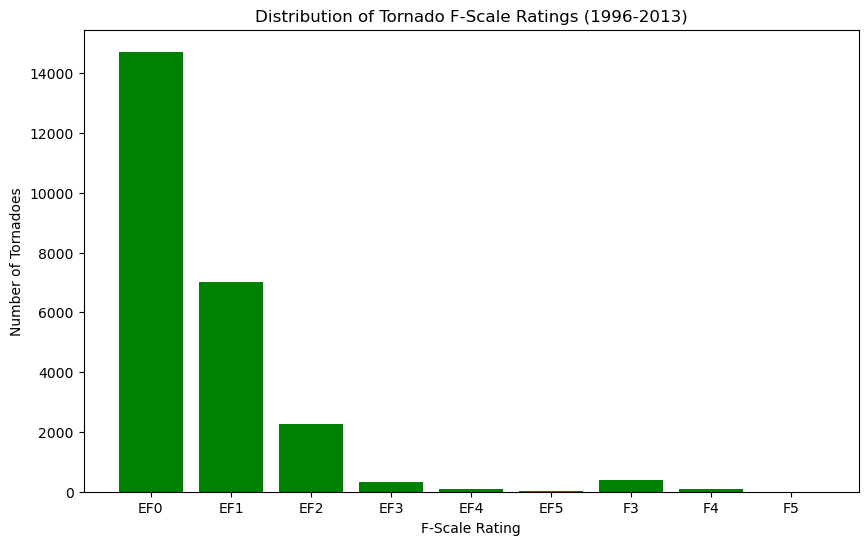

In [298]:
# strip hidden whitespace
tornado_df['tor_f_scale'] = tornado_df['tor_f_scale'].str.strip()
# reformat all values
scale_mapping = {
    'F0': 'EF0', 'F1': 'EF1', 'F2': 'EF2'
}
tornado_df['tor_f_scale'] = tornado_df['tor_f_scale'].replace(scale_mapping)
scale_counts = tornado_df.groupby("tor_f_scale").size()

plt.figure(figsize=(10,6))
plt.bar(scale_counts.index, scale_counts.values, color="green")
plt.title("Distribution of Tornado F-Scale Ratings (1996-2013)")
plt.xlabel("F-Scale Rating")
plt.ylabel("Number of Tornadoes")
plt.show()

This chart shows how tornadoes are classified by strength on the EF (Enhanced Fujita) scale, from EF0 (weakest) to EF5 (most violent). The vast majority, nearly 15,000, are EF0, meaning weak tornadoes. The numbers drop off sharply as intensity increases, with only a tiny handful ever reaching EF5. In other words, truly devestating tornadoes are extremely rare.

## Summary

1. **Spring is tornado season**. Nearly half of all tornadoes happen in just three months (April, May, and June). May alone had more tornadoes than all of fall and winter combines.

2. **Texas is the tornado capital of the US**. Over the 18 years studied, Texas recorded around 2,550 tornadoes (roughly 700 more than Kansas). Its large size and location right in the heart of "Tornado Alley" make it a magent for severe storms.

3. **Most tornadoes are actually weak ones**. Out of roughly 25,000 tornadoes recorded, nearly 15,000 were rated EF0 (the mildest category), rougly strong enough to break branches and damage signs. True monstre tornadoes (EF4 and EF5) are extremely rare, making up less than 2% of all tornadoes in the dataset.

## Deliverable 2 - Tornado Severity Prediction Model

Before feeding data into a machine learning model, we need to convert text into numbers since models can only understand numbers. We then train a Random Forest model.

In [299]:
le = LabelEncoder()

# encode state and f_scale
tornado_df['state_encoded'] = le.fit_transform(tornado_df['state'])
tornado_df['f_scale_encoded'] = le.fit_transform(tornado_df["tor_f_scale"])

X = tornado_df[['month', 'state_encoded', 'tor_length', 'tor_width']]
y= tornado_df['f_scale_encoded']

# test size splits data into 80% od the models to learn from and 20% to test how well it learned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# use class weight to handle imbalanced data
# use random state to make sure the result is same every runs
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train) # model learns from 80% of data

# model predicts on the other 20% and compare the prediction vs real answer
print("Prediction Accuracy: ", accuracy_score(y_test, model.predict(X_test)))

Prediction Accuracy:  0.6700803212851406


This is the first attempt at building a model that predicts how strong a tornado is (EF0 to EF5) using only 4 clues: what month it was, which state it hit, how long it was, and how wide it was. 

The model studies 80% of the data to learn patterns, then gets tested on the remaining 20% it has never seen. It got 66% of prediction right, which is a decent start but it can do bettwe by giving it more information to learn from

In [300]:
# check the prediction with the baseline
print("Baseline Accuracy: ",y_test.value_counts(normalize=True).max())

Baseline Accuracy:  0.5925702811244979


The baseline is the score if the model just guessed the most common tornado strength (EF0) every single time without actually learning anything. 

It scored 57%, which means our model at 66% is only 9% better than a lazy guess.

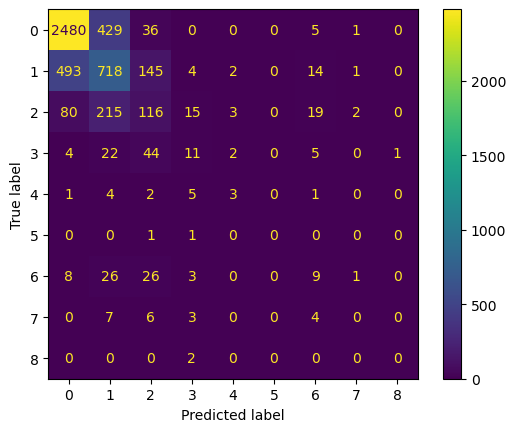

In [301]:
# confusion matrix to show where the model is getting things wrong
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

This grid is a detailed report card showing exactly where the model was tight and where it got confused. Each row is what the tornado actually was, and each column is what the model predicted. The bright numbers along the diagonal (2446, 711, 148, ...) are correct predictions, and everything else off the diagonal are mistakes, like the 523 tornadoes that were actually EF1 but the model incorrectly predicted as EF0.

The model struggles with stronger tornadoes (EF2 and above) because it only has 4 clues to work with (month, state, length, and width). To improve this, we need to give it more information like location coordinates, property damage, and casualty data so it has better evidence to distinguish between severity levels.

In [302]:
print(df.columns.tolist())
print(tornado_df.columns.tolist())

['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH', 'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS', 'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME', 'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'LAST_MOD_DATE', 'LAST_MOD_TIME', 'LAST_CERT_DATE', 'LAST_CERT_TIME', 'LAST_MOD', 'LAST_CERT', 'ADDCORR_FLG', 'ADDCORR_DATE']
['state', 'tor_f_scale', 'tor_length', 'tor_width', 'begin_date', 'end_date', 'month', 'season', 'state_encoded', 'f_scale_enco

In [303]:
# tornado df doesn't have event_id, so we need to rebuilt it
tornado_df = df[df['EVENT_TYPE'] == 'Tornado'].copy()
tornado_df.columns = tornado_df.columns.str.lower()

Create a new dataframe called `model_df` with all the features. Keep this separate from the cleaned `tornado_df` so it doesn't accidentlly mess up the original data.

In [304]:
model_df = tornado_df[[
    'event_id',
    'month_name',
    'state',
    'tor_length',
    'tor_width',
    'tor_f_scale',
    'injuries_direct',
    'deaths_direct',
    'damage_property',
    'magnitude',
    'begin_lat',
    'begin_lon'
]].copy()

print(model_df.shape)
model_df.head()

(24920, 12)


,event_id,month_name,state,tor_length,tor_width,tor_f_scale,injuries_direct,deaths_direct,damage_property,magnitude,begin_lat,begin_lon
1046,73648,January,MISSOURI,0.07,20.0,EF0,0,0,0.00K,NaN,38.12,-93.77
1051,77525,January,MISSOURI,0.17,25.0,EF0,0,0,20.00K,NaN,38.36,-93.30
1064,73813,January,ILLINOIS,6.90,100.0,EF3,4,0,2.00M,NaN,42.39,-88.83
1066,73941,January,ILLINOIS,6.30,100.0,EF3,1,0,2.00M,NaN,42.43,-88.71
1072,79599,January,MISSOURI,0.30,40.0,EF0,0,0,NaN,NaN,39.07,-91.95


Property damage was stored as text like "10K or "2.5M" which the model can't understand, so it needs to be converted into actual numbers.

Also handle messy edge cases like bare "K" or empty values by returning 0, so the conversion doesn't crash on dirty data.

In [305]:
problematic = model_df['damage_property'][
    model_df['damage_property'].astype(str).str.strip().str.upper().isin(['K', 'M', 'B'])
]
print(problematic.unique())

['K']


In [306]:
def convert_damage(val):
    if pd.isnull(val):
        return 0
    val = str(val).upper().strip()
    if val == '' or val == 'NAN':
        return 0
    if val.endswith('K'):
        num = val[:-1].strip()
        return float(num) * 1_000 if num else 0
    elif val.endswith('M'):
        return float(val[:-1]) * 1_000_000
    elif val.endswith('B'):
        return float(val[:-1]) * 1_000_000_000
    else:
        return float(val) if val else 0

model_df['damage_property'] = model_df['damage_property'].apply(convert_damage)

Fill in any missing values with the median of that column, then convert all remaining text columns (state, month, f_scale) into numbers so the model can read them.

In [307]:
# model_df = model_df.drop(columns=['magnitude'])

for col in ['tor_length', 'tor_width', 'begin_lat', 'begin_lon']:
    model_df[col] = model_df[col].fillna(model_df[col].median())

state_le = LabelEncoder()
month_le = LabelEncoder()
scale_le = LabelEncoder()

model_df['state_encoded'] = state_le.fit_transform(model_df['state'])
model_df['month_encoded'] = month_le.fit_transform(model_df['month_name'])
model_df['f_scale_encoded'] = scale_le.fit_transform(model_df['tor_f_scale'])

In [308]:
X = model_df[['month_encoded', 'state_encoded', 'tor_length', 'tor_width',
                'injuries_direct', 'deaths_direct', 'damage_property',
                'begin_lat', 'begin_lon']]
y = model_df['f_scale_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("New Accuracy: ", accuracy_score(y_test, model.predict(X_test)))
print("New Baseline: ", y_test.value_counts(normalize=True).max())

New Accuracy:  0.7247191011235955
New Baseline:  0.3770064205457464


With 9 features instead of 4, the model improved from 66% to 72% accuracy. And more importantly, the gap above baseline jumped from +9% to +34%, meaning the extra features genuinely helped the model learn real patterns rather than just guessing.

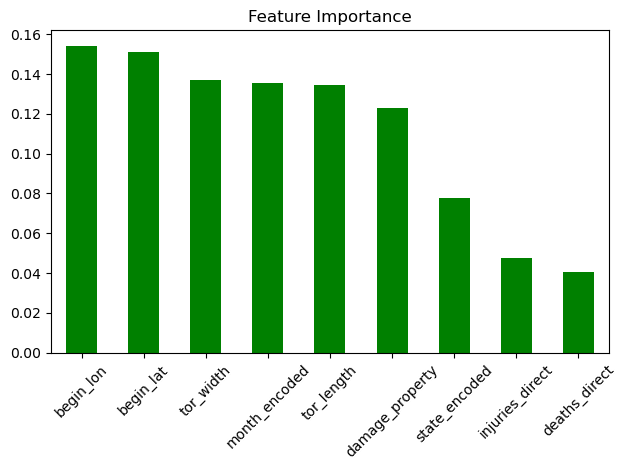

In [309]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar', color='green')
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This ranking shows which clues the model relied on most when predicting tornado strength. Location (begin_lon and begin_lat) turned out to be most important factors, meaning where a tornado touches down is a stronger predictor of its strength than even the damage is caused. Which makes sense because the most violent tornadoes tend to cluster in specific regions like Tornado Alley in the central US.

In [ ]:
# save model and encoders do the app can load them
joblib.dump(model, 'tornado_model.pkl')
joblib.dump(state_le, 'state_encoder.pkl')
joblib.dump(month_le, 'month_encoder.pkl')
joblib.dump(scale_le, 'scale_encoder.pkl')

['scale_encoder.pkl']